<a href="https://colab.research.google.com/github/Krishishah7/ai-learning-series/blob/main/01_machine_learning_foundations/38_random_forest_classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification

from sklearn.model_selection import train_test_split

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score

In [3]:
X, y = make_classification(
    n_samples=500,
    n_features=10,
    n_informative=5,
    random_state=42
)

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [5]:
dt = DecisionTreeClassifier(
    random_state=42
)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

dt_acc = accuracy_score(
    y_test,
    dt_pred
)

print(
    "Decision Tree Accuracy:",
    dt_acc
)

Decision Tree Accuracy: 0.88


In [6]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

rf_acc = accuracy_score(
    y_test,
    rf_pred
)

print(
    "Random Forest Accuracy:",
    rf_acc
)

Random Forest Accuracy: 0.92


In [7]:
comparison = pd.DataFrame({
    "Model":[
        "Decision Tree",
        "Random Forest"
    ],

    "Accuracy":[
        dt_acc,
        rf_acc
    ]
})

comparison

,Model,Accuracy
0,Decision Tree,0.88
1,Random Forest,0.92


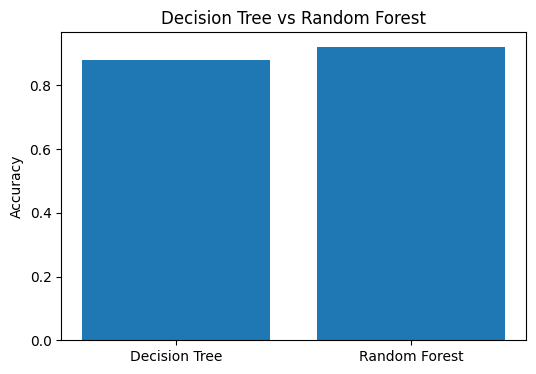

In [8]:
plt.figure(figsize=(6,4))

plt.bar(
    comparison["Model"],
    comparison["Accuracy"]
)

plt.ylabel("Accuracy")

plt.title(
    "Decision Tree vs Random Forest"
)

plt.show()

In [9]:
importance = pd.DataFrame({
    "Feature":
    range(X.shape[1]),

    "Importance":
    rf.feature_importances_
})

importance.sort_values(
    by="Importance",
    ascending=False
)

,Feature,Importance
0,0,0.201372
1,1,0.186734
5,5,0.170865
7,7,0.092161
3,3,0.089752
8,8,0.089520
2,2,0.070669
9,9,0.037224
6,6,0.032693
4,4,0.029010


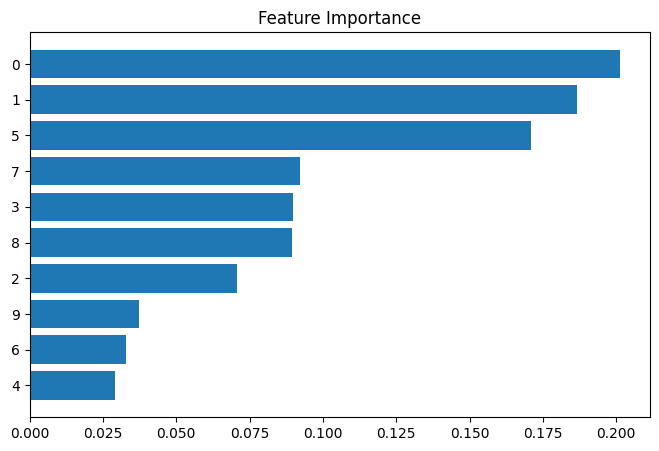

In [10]:
importance = importance.sort_values(
    by="Importance",
    ascending=True
)

plt.figure(figsize=(8,5))

plt.barh(
    importance["Feature"].astype(str),
    importance["Importance"]
)

plt.title(
    "Feature Importance"
)

plt.show()

## Conclusion

Random Forest combines multiple decision trees to improve prediction performance.

Observations:
- Ensemble learning reduces overfitting compared to a single decision tree.
- Multiple trees vote to make final predictions.
- Random Forest often achieves higher accuracy.
- Feature importance helps identify influential features.